## Prepare data for analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

business = pd.read_json("/content/drive/MyDrive/163/yelp_academic_dataset_business.json", lines=True)


In [4]:
restaurants = business[
    business["categories"].str.contains("Restaurant", na=False)
]

In [5]:
restaurants = restaurants[restaurants["review_count"] >= 50]


In [6]:
restaurants["review_count"].min()

50

## Analysis

In [7]:
## t-test
import numpy as np
from scipy.stats import ttest_ind
restaurants["log_reviews"] = np.log1p(restaurants["review_count"])
open_reviews = restaurants[restaurants["is_open"] == 1]["log_reviews"]
closed_reviews = restaurants[restaurants["is_open"] == 0]["log_reviews"]

ttest_ind(open_reviews, closed_reviews)

TtestResult(statistic=np.float64(22.85895712385208), pvalue=np.float64(3.1503186675855854e-114), df=np.float64(20570.0))

 There is a big difference in review counts between open and closed restaurants -> Open restaurants have significantly higher review counts than closed ones.

 For hyp: More reviews -> more likely to be open

In [ ]:
ttest_ind(
    restaurants[restaurants["is_open"] == 1]["stars"],
    restaurants[restaurants["is_open"] == 0]["stars"]
)

TtestResult(statistic=np.float64(11.938825566546866), pvalue=np.float64(9.528338136377754e-33), df=np.float64(20570.0))

There is a difference in star ratings between open and closed restaurants but the difference is small. So while ratings are different they might not be a string predictor of restaurant operating status.

In [ ]:
## chi-square test
#get categories for restaurants
restaurants["main_category"] = restaurants["categories"].str.split(",").str[0]
#create table for test
#test
from scipy.stats import chi2_contingency
table = pd.crosstab(restaurants["main_category"], restaurants["is_open"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(467.89814452799567), pvalue=np.float64(3.7478211375390964e-08), dof=314, expected_freq=array([[2.22331324e+00, 6.77668676e+00],
       [4.94069609e+00, 1.50593039e+01],
       [2.47034805e-01, 7.52965195e-01],
       [4.94069609e-01, 1.50593039e+00],
       [9.88139218e-01, 3.01186078e+00],
       [2.47034805e+00, 7.52965195e+00],
       [2.47034805e-01, 7.52965195e-01],
       [1.56373031e+02, 4.76626969e+02],
       [1.84287964e+02, 5.61712036e+02],
       [2.47034805e-01, 7.52965195e-01],
       [2.47034805e-01, 7.52965195e-01],
       [7.41104414e-01, 2.25889559e+00],
       [7.41104414e-01, 2.25889559e+00],
       [7.41104414e-01, 2.25889559e+00],
       [4.94069609e-01, 1.50593039e+00],
       [4.94069609e-01, 1.50593039e+00],
       [2.47034805e-01, 7.52965195e-01],
       [1.87746451e+01, 5.72253549e+01],
       [4.17488820e+01, 1.27251118e+02],
       [9.88139218e-01, 3.01186078e+00],
       [1.43280187e+01, 4.36719813e+01],
       [3

Null hyp: Restaurant category and is_open are independent.

Results: p-value = 3.7478211375390964e-08 -> extremely small

There is a statistically significant relationship between restaurant category and operating status. Reject null hyp. -> Some restaurant categories are more likely to be open or closed than others.



## Sentiment analysis

In [8]:
# Import TextBlob for sentiment analysis.
# TextBlob assigns each review a polarity score:
#   -1.0 = very negative
#    0.0 = neutral
#   +1.0 = very positive
from textblob import TextBlob
import pandas as pd
# Import garbage collection to free memory after each chunk.
import gc

# Get the set of restaurant business IDs from our filtered restaurant dataset.
# We only want to process reviews that belong to restaurants in our analysis.
restaurant_ids = set(restaurants["business_id"])

# Create a list to store partial results from each chunk.
# Each chunk will produce:
#   business_id
#   sentiment_sum = sum of sentiment scores
#   review_n = number of reviews
chunk_results = []

# Read the Yelp review dataset in chunks of 10,000 rows at a time.
# This is necessary because the full review dataset is very large and
# may not fit into memory all at once.
for chunk in pd.read_json(
    "/content/drive/MyDrive/163/yelp_academic_dataset_review.json",
    lines=True,
    chunksize=10000
):
    # Keep only reviews for restaurants in our dataset.
    filtered = chunk[chunk["business_id"].isin(restaurant_ids)].copy()

    # If no reviews in this chunk match our restaurants, skip it.
    if filtered.empty:
        continue

    # Compute sentiment for each review.
    # TextBlob returns a polarity score between -1 and 1.
    filtered["sentiment"] = filtered["text"].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )

    # Aggregate sentiment within this chunk.
    # For each restaurant:
    #   sentiment_sum = total sentiment across all reviews in the chunk
    #   review_n = number of reviews in the chunk
    agg_chunk = filtered.groupby("business_id").agg(
        sentiment_sum=("sentiment", "sum"),
        review_n=("sentiment", "size")
    ).reset_index()

    # Save this chunk's aggregated results.
    chunk_results.append(agg_chunk)

    # Delete temporary objects to free memory.
    del chunk, filtered, agg_chunk
    gc.collect()

# combine all chunks into one DataFrame.
sentiment_df = pd.concat(chunk_results)

# Aggregate again across all chunks.
# Since the same restaurant may appear in multiple chunks,
# we sum the sentiment totals and review counts.
sentiment_df = sentiment_df.groupby("business_id").agg(
    sentiment_sum=("sentiment_sum", "sum"),
    review_n=("review_n", "sum")
).reset_index()

# Compute the final average sentiment for each restaurant.
sentiment_df["avg_sentiment"] = (
    sentiment_df["sentiment_sum"] / sentiment_df["review_n"]
)

# Merge the average sentiment feature into the main restaurant dataset.
# Each restaurant now has one additional column:
#   avg_sentiment
restaurants = restaurants.merge(
    sentiment_df[["business_id", "avg_sentiment"]],
    on="business_id",
    how="left"
)

In [9]:
from scipy.stats import ttest_ind

ttest_ind(
    restaurants[restaurants["is_open"] == 1]["avg_sentiment"].dropna(),
    restaurants[restaurants["is_open"] == 0]["avg_sentiment"].dropna()
)

TtestResult(statistic=np.float64(6.967258052344872), pvalue=np.float64(3.329404926366119e-12), df=np.float64(20570.0))

In [12]:
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
restaurants.head()


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,log_reviews,avg_sentiment,status
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.394449,0.280990,Open
1,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,0,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'...",4.615121,0.294617,Closed
2,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,1,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-...",5.505332,0.343521,Open
3,ROeacJQwBeh05Rqg7F6TCg,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,1,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20...",5.327876,0.298164,Open
4,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,5505 S Virginia St,Reno,NV,89502,39.476117,-119.789339,2.5,339,1,"{'RestaurantsGoodForGroups': 'True', 'Restaura...","Restaurants, Italian","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",5.828946,0.134757,Open


Text(0.5, 1.0, 'Average Sentiment by Restaurant Status')

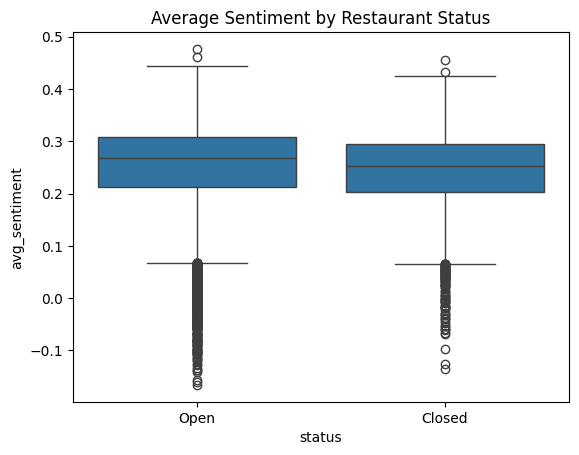

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="status", y="avg_sentiment", data=restaurants)
plt.title("Average Sentiment by Restaurant Status")

In [38]:
from google.colab import files

import plotly.express as px
fig = px.box(
    restaurants,
    x="status",
    y="avg_sentiment",
    title="Average Sentiment by Restaurant Status"
)

fig.show()
fig.write_html("hyp5_plot1.html")
files.download("hyp5_plot1.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Open restaurants have slightly higher median sentiment, but the heavy overlap indicates sentiment is not a strong distinguishing factor.

Text(0.5, 1.0, 'Distribution of Average Sentiment by Restaurant Status')

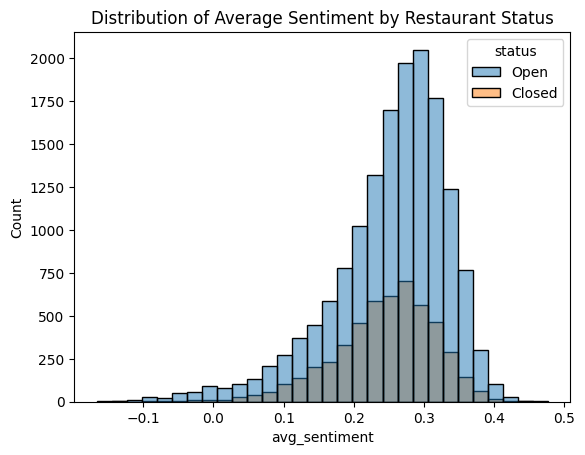

In [ ]:
sns.histplot(data=restaurants, x="avg_sentiment", hue="status", bins=30)
plt.title("Distribution of Average Sentiment by Restaurant Status")


In [39]:
fig = px.histogram(
    restaurants,
    x="avg_sentiment",
    color="status",
    #nbins=30,
    opacity=0.6,
    barmode="overlay",
    histnorm="probability density",
    title="Distribution of Average Sentiment by Restaurant Status"
)

fig.show()
fig.write_html("hyp5_plot2.html")
files.download("hyp5_plot2.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

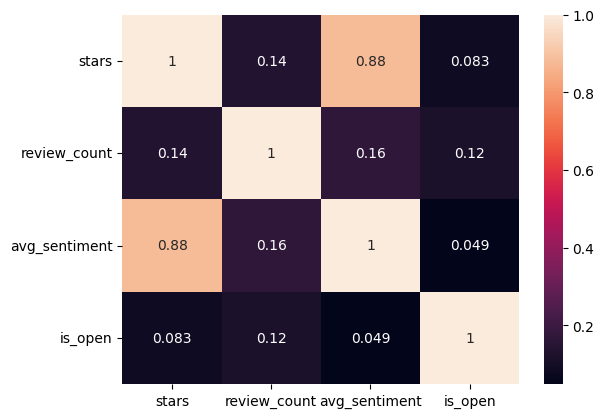

In [ ]:
sns.heatmap(
    restaurants[["stars","review_count","avg_sentiment", "is_open"]].corr(),
    annot=True
)



In [ ]:
fig = px.scatter(
    restaurants,
    x="stars",
    y="avg_sentiment",
    color="status",
    title="Stars vs Sentiment by Restaurant Status",
    opacity=0.5
)

fig.show()

In [36]:
fig = px.histogram(
    restaurants,
    x="avg_sentiment",
    color="status",
    marginal="box",
    #nbins=30,
    opacity=0.6,
    barmode="overlay",
    histnorm="probability density",
    title="Interactive Sentiment Distribution"
)

fig.show()

Open restaurants exhibit slightly higher average sentiment than closed restaurants. However, the difference is small and the distributions overlap heavily, indicating that sentiment alone has limited predictive power for determining whether a restaurant remains open. While sentiment aligns closely with star ratings, it does not strongly differentiate between operating and closed businesses.

## Complaint Frequency

In [14]:
# List of words that indicate possible customer complaints.
# These are terms commonly found in negative reviews.
complaint_words = [
    "slow", "rude", "overpriced", "bad", "terrible",
    "awful", "cold", "bland", "dirty", "wait"
]

In [15]:
# Function to count how many complaint words appear in a review.
def count_complaints(text):
    # Convert the review text to lowercase so matching is case-insensitive.
    text = str(text).lower()

    # For each complaint word, check whether it appears in the review.
    # True counts as 1 and False counts as 0.
    # Example:
    # "slow service and rude staff" -> contains "slow" and "rude" -> returns 2
    return sum(word in text for word in complaint_words)

In [16]:
# Get all restaurant business IDs from our restaurant dataset.
# We only want to process reviews for these restaurants.
restaurant_ids = set(restaurants["business_id"])


# Dictionary to store the total number of complaint words
# across all reviews for each restaurant.
# Example:
# complaint_totals["abc123"] = 42
complaint_totals = {}


# Dictionary to store the total number of reviews
# processed for each restaurant.
# Example:
# review_counts["abc123"] = 100
review_counts = {}


# Read the Yelp review dataset in chunks of 10,000 rows.
# This avoids loading the entire large review file into memory at once.
for chunk in pd.read_json(
    "/content/drive/MyDrive/163/yelp_academic_dataset_review.json",
    lines=True,
    chunksize=10000
):

    # Keep only reviews belonging to restaurants in our dataset.
    chunk = chunk[chunk["business_id"].isin(restaurant_ids)]


    # Compute the complaint score for each review.
    # This is the number of complaint words found in the review text.
    chunk["complaints"] = chunk["text"].apply(count_complaints)


    # Process each review in the chunk.
    for _, row in chunk.iterrows():
        # Get the restaurant ID.
        bid = row["business_id"]

        # Add this review's complaint score to the restaurant's total.
        # If the restaurant is not already in the dictionary, start at 0.
        complaint_totals[bid] = (
            complaint_totals.get(bid, 0) + row["complaints"]
        )

        # Increase the review count for this restaurant by 1.
        review_counts[bid] = (
            review_counts.get(bid, 0) + 1
        )


In [17]:
# Convert total complaints into average complaints per review.
# Formula:
#   avg_complaints = total complaint words / number of reviews
#
# Example:
#   30 complaint words across 100 reviews -> 0.30
avg_complaints = {
    bid: complaint_totals[bid] / review_counts[bid]
    for bid in complaint_totals
}


In [18]:
# Convert the dictionary into a DataFrame.
# The business_id becomes the index initially.
complaints_df = pd.DataFrame.from_dict(
    avg_complaints,
    orient="index",
    columns=["avg_complaints"]
).reset_index()


# Rename the index column to business_id.
complaints_df = complaints_df.rename(
    columns={"index": "business_id"}
)


# Merge the average complaint feature into the main restaurant dataset.
# Each restaurant now gets one additional column:
#   avg_complaints
restaurants = restaurants.merge(
    complaints_df,
    on="business_id",
    how="left"
)

# If a restaurant did not receive a complaint score
# (for example, if no reviews were processed),
# replace missing values with 0.
restaurants["avg_complaints"] = (
    restaurants["avg_complaints"].fillna(0)
)

In [19]:
ttest_ind(
    restaurants[restaurants["is_open"] == 1]["avg_complaints"],
    restaurants[restaurants["is_open"] == 0]["avg_complaints"]
)

TtestResult(statistic=np.float64(-18.35512725581043), pvalue=np.float64(1.185394274710695e-74), df=np.float64(20570.0))

In [40]:
import plotly.express as px

fig = px.box(
    restaurants,
    x="status",
    y="avg_complaints",
    title="Complaint Frequency by Restaurant Status"
)

fig.show()
fig.write_html("hyp4_plot1.html")
files.download("hyp4_plot1.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
fig = px.histogram(
    restaurants,
    x="avg_complaints",
    color="status",
    barmode="overlay",
    opacity=0.6,
    histnorm="probability density",
    title="Distribution of Complaint Frequency by Status"
)

fig.show()
fig.write_html("hyp4_plot2.html")
files.download("hyp4_plot2.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
restaurants[["avg_complaints", "is_open"]].corr()

,avg_complaints,is_open
avg_complaints,1.000000,-0.126944
is_open,-0.126944,1.000000


A two-sample t-test shows a significant difference in complaint frequency between open and closed restaurants (t = -18.36, p < 0.001). Closed restaurants have higher average complaint frequency compared to open restaurants, indicating that negative customer experiences are associated with a greater likelihood of business closure.

This suggests that poor customer experiences, as reflected by complaint-related language in reviews, may contribute to a restaurant’s inability to remain in operation.

However, the magnitude of the difference is relatively small, indicating that complaint frequency alone is not a strong predictor of operating status.